In [65]:
import numpy as np
from qiskit import qpy
from qiskit.circuit.library import PauliEvolutionGate
import sys
import os

utils_path = os.path.abspath("../lib")

sys.path.append(utils_path)
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [66]:
import matplotlib.pyplot as plt
plt.figure(dpi=300)  # Default is 100
import numpy as np
import qiskit.qpy as qpy
import pickle
import json
import matplotlib.patches as mpatches
from numba import njit
from numba.typed import List
from plotting import *
from readings import *
from tile_process import *
from double_pack import *
import pickle


<Figure size 1920x1440 with 0 Axes>

In [67]:
def stilbene_packing(excitations, separation, seam_lst,
                       file_name = "./tiles/second_input_tiles.txt", if_double = False):
    bounding_width, placed_tiles_lst = first_pack(excitations, separation, seam_lst)
    if if_double:
        return bounding_width, placed_tiles_lst
    def reexport_tiles(placed_tiles):
        new_tiles = []
        for placed_tile in placed_tiles:
            cur_tile = Tile(placed_tile.w, placed_tile.h, placed_tile.dx, placed_tile.dy)
            cur_tile.pauli = placed_tile.pauli
            cur_tile.t = placed_tile.t
            new_tiles.append(cur_tile)
        return new_tiles
    
    def sort_key(tile):
        inter_module = (tile.dy - seam_lst[0]) * (tile.dy + tile.h - seam_lst[0])
        if inter_module < 0:
            inter_module = -1
        else:
            inter_module = 1
        if inter_module == -1:
            diff = min([abs(seam_lst[0] - (tile.h + tile.dy)), abs(seam_lst[0] - tile.dy)])
        else:
            diff = 0
        criteria = diff + 100 * inter_module
        criteria = (criteria, tile.dy, tile.h)
        return criteria

    ordered_placed_tiles = sorted(placed_tiles_lst, key=sort_key)
    filename = "./tiles/second_input_tiles.txt"

    new_tiles = reexport_tiles(ordered_placed_tiles)
    print(len(new_tiles), "new tile length")
    export_inter_intra(new_tiles, filename, seam_lst)
    
    print(f"second output has {len(new_tiles)} tiles")
    separation_file = "./tiles/separation.txt"
    export_separation(separation_file, separation, True)
    second_packing_c = "../lib/double_packing.exe"
    second_bounding_width, second_placed_tiles_lst = packing_with_c(new_tiles,second_packing_c)
    filename = './tiles/second_result_tiles.txt'
    bounding_width, placed_tiles_lst = read_placed_tiles(filename)
    print(f"second output has {len(placed_tiles_lst)} tiles")
    return bounding_width, placed_tiles_lst

In [68]:
def process_placed_tile(placed_tiles_lst, overlap_lst):
    result_tile = []
    for placed_tile in placed_tiles_lst:
        new_tile = placed_tile.copy()
        if placed_tile in overlap_lst or overlap_lst == []:
            new_tile.overlap = True
        else:
            new_tile.overlap = False
        result_tile.append(new_tile)
    return result_tile

def draw_packing_overlap(placed_tiles_lst, bounding_width, bounding_height, seam_lst, intra_color="tomato", inter_color="cyan", new_inter_color = "olive",
                         new_intra_color = "tomato"):
    """Draws the placement of tiles with color and boundaries."""
    fig, ax = plt.subplots(figsize=(10, 6), dpi = 300)
    ax.set_aspect('auto')

    # Define the grid size and spacing between cells
    cell_size = 1  # Define the size of each grid cell (uniform size)

    # Create a colormap for each tile
    colors = plt.cm.get_cmap("tab10", len(placed_tiles_lst))
    # Draw each tile with a unique color and boundary
    for placed_tile in placed_tiles_lst:  # Only unpack two values here
        tile_x, w, h, dx, dy = placed_tile.params()
        overlap = placed_tile.overlap
        if overlap:
            rect = patches.Rectangle((tile_x + dx, dy), w, h, facecolor=new_intra_color)
        else:
            rect = patches.Rectangle((tile_x + dx, dy), w, h, facecolor=intra_color)
        for seam in seam_lst:
            if overlap and dy < seam and dy + h >= seam:
                rect = patches.Rectangle((tile_x + dx, dy), w, h, facecolor=new_inter_color)
            elif dy < seam and dy + h >= seam:
                rect = patches.Rectangle((tile_x + dx, dy), w, h, facecolor=inter_color)
        ax.add_patch(rect)

    # Set limits based on bounding box size
    ax.set_xlim(0, bounding_width)
    ax.set_ylim(0, bounding_height-1)

    # Hide the axis ticks for a cleaner look
    ax.set_xticks([])
    ax.set_yticks([])
    for seam in seam_lst:
        plt.axhline(seam - 0.5, color="purple", linewidth=3, linestyle = "--")
    plt.text(0.90, 0.03, rf"$d_c$ = {bounding_width}", ha='right', va='bottom', transform=plt.gcf().transFigure, fontsize = 30)
    plt.show()





In [69]:
def read_all_g(directory):
    a_idx_file = directory + "/a_idxs.json"
    i_idx_file = directory + "/i_idxs.json"
    all_g_file = directory + "/all_g.json"

    with open(a_idx_file, "rb") as f:
        a_idxs = pickle.load(f)
    
    with open(i_idx_file, "rb") as f:
        i_idxs = pickle.load(f)

    with open(all_g_file, "rb") as f:
        all_g = pickle.load(f)
    return a_idxs, i_idxs, all_g

def create_excitation(a_index, i_index, all_g, epsilon):
    excitations = []
    for [gradient, i] in all_g:
        gradient = abs(gradient)
        if gradient > epsilon:
            cur_a = a_index[i].copy()
            cur_i = i_index[i].copy()
            cur_excitation = [cur_a, cur_i]
            excitations.append(cur_excitation)
    return excitations

def swap_index(excitations, i, j):
    result = copy.deepcopy(excitations)
    for excitation in result:
        for pair in excitation:
            for k in range(2):
                idx = pair[k]
                if idx == i:
                    pair[k] = j
                elif idx == j:
                    pair[k] = i
    return result

In [70]:
def process_placed_tile(placed_tiles_lst, overlap_lst):
    result_tile = []
    for placed_tile in placed_tiles_lst:
        new_tile = placed_tile.copy()
        if placed_tile in overlap_lst or overlap_lst == []:
            new_tile.overlap = True
        else:
            new_tile.overlap = False
        result_tile.append(new_tile)
    return result_tile

def draw_packing_overlap(placed_tiles_lst, bounding_width, bounding_height, seam_lst, intra_color="tomato", inter_color="cyan", new_inter_color = "olive",
                         new_intra_color = "tomato"):
    """Draws the placement of tiles with color and boundaries."""
    fig, ax = plt.subplots(figsize=(10, 6), dpi = 300)
    ax.set_aspect('auto')

    # Define the grid size and spacing between cells
    cell_size = 1  # Define the size of each grid cell (uniform size)

    # Create a colormap for each tile
    colors = plt.cm.get_cmap("tab10", len(placed_tiles_lst))
    # Draw each tile with a unique color and boundary
    for placed_tile in placed_tiles_lst:  # Only unpack two values here
        tile_x, w, h, dx, dy = placed_tile.params()
        overlap = placed_tile.overlap
        if overlap:
            rect = patches.Rectangle((tile_x + dx, dy), w, h, facecolor=new_intra_color)
        else:
            rect = patches.Rectangle((tile_x + dx, dy), w, h, facecolor=intra_color)
        for seam in seam_lst:
            if overlap and dy < seam and dy + h >= seam:
                rect = patches.Rectangle((tile_x + dx, dy), w, h, facecolor=new_inter_color)
            elif dy < seam and dy + h >= seam:
                rect = patches.Rectangle((tile_x + dx, dy), w, h, facecolor=inter_color)
        ax.add_patch(rect)

    # Set limits based on bounding box size
    ax.set_xlim(0, bounding_width)
    ax.set_ylim(0, bounding_height-1)

    # Hide the axis ticks for a cleaner look
    ax.set_xticks([])
    ax.set_yticks([])
    for seam in seam_lst:
        plt.axhline(seam - 0.5, color="purple", linewidth=3, linestyle = "--")
    plt.text(0.90, 0.03, rf"$d_c$ = {bounding_width}", ha='right', va='bottom', transform=plt.gcf().transFigure, fontsize = 30)
    plt.show()





In [71]:
# Replace with your .qpy file path
parent_dir = "C:/Users/24835/Desktop/homework/uiuc/Covey/chem"
filename = "/stilbene/dist_0"
filename = parent_dir + filename


# filename = "polyenes/n4/for-plot/circ_dump.qpy"

# filename = "polyenes/n2/for-plot/circ_dump.qpy"

a_idxs, i_idxs, all_g = read_all_g(filename)
all_g = [[item, i] for i, item in enumerate(all_g)]
lst = [max(excitation) for excitation in a_idxs]
print(max(lst))

19


In [72]:
n = 20
epsilon = 5e-3
excitations = create_excitation(a_idxs, i_idxs, all_g, epsilon)
f_orbs = [4,2,4]
excitations = orbital_reordering(excitations, f_orbs)
print(excitations)
excitations = excitations
# excitations_swap = swap_index(excitations, 23, )
excitations_swap = swap_index(excitations, 19, 14)
print(excitations_swap)

# print((excitations_swap))
tiles = create_circuit_tile(excitations_swap)
# for tile in tiles:
#     print(tile.t)

[[array([4, 0], dtype=uint8), array([11,  3], dtype=uint8)], [array([4, 0], dtype=uint8), array([9, 7], dtype=uint8)], [array([1, 0], dtype=uint8), array([9, 2], dtype=uint8)], [array([5, 4], dtype=uint8), array([11,  6], dtype=uint8)], [array([5, 0], dtype=uint8), array([9, 7], dtype=uint8)], [array([1, 4], dtype=uint8), array([11,  3], dtype=uint8)], [array([5, 1], dtype=uint8), array([11,  2], dtype=uint8)], [array([5, 1], dtype=uint8), array([9, 6], dtype=uint8)], [array([6, 2], dtype=uint8), array([10,  1], dtype=uint8)], [array([6, 2], dtype=uint8), array([8, 5], dtype=uint8)], [array([3, 2], dtype=uint8), array([8, 1], dtype=uint8)], [array([7, 6], dtype=uint8), array([10,  5], dtype=uint8)], [array([7, 3], dtype=uint8), array([10,  0], dtype=uint8)], [array([7, 3], dtype=uint8), array([8, 4], dtype=uint8)], [array([8, 0], dtype=uint8), array([9, 2], dtype=uint8)], [array([10,  0], dtype=uint8), array([11,  2], dtype=uint8)], [array([8, 4], dtype=uint8), array([9, 6], dtype=uint

In [73]:
print(excitations[0])
test = [[[8, 9], [10, 11]]]
print(orbital_reordering(test, f_orbs))

[array([4, 0], dtype=uint8), array([11,  3], dtype=uint8)]
[[[14, 15], [4, 5]]]


In [74]:
lst = [max(excitation[1]) for excitation in excitations]
print(max(lst))

19


In [75]:
separation = 0
seam_lst = [10]
bounding_width, placed_tiles_lst = stilbene_packing(excitations_swap, separation, seam_lst, if_double=False)


first input has 480 tiles
Tiles successfully exported to ./tiles/inter_intra_tiles.txt
Current Directory: c:\Users\24835\Desktop\homework\uiuc\Covey\chem\H-chain\src\double_packing\lib\tile_packing.exe
sorted
Tiles successfully exported to C:/Users/24835/Desktop/homework/uiuc/Covey/chem/H-chain/test_tiles.txt
Bounding Width: 12070, Height: 0
Total tiles: 0
Bounding Width: 10880, Height: 19
Total tiles: 480
first output has 480 tiles
480 new tile length
Tiles successfully exported to ./tiles/second_input_tiles.txt
second output has 480 tiles
Current Directory: c:\Users\24835\Desktop\homework\uiuc\Covey\chem\H-chain\src\double_packing\lib\tile_packing.exe
sorted
Tiles successfully exported to C:/Users/24835/Desktop/homework/uiuc/Covey/chem/H-chain/test_tiles.txt
Bounding Width: 12070, Height: 0
Total tiles: 0
Bounding Width: 4496, Height: 19
Total tiles: 480
second output has 480 tiles


C:\Users\24835\AppData\Local\Temp\ipykernel_17324\1392929189.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", len(placed_tiles_lst))


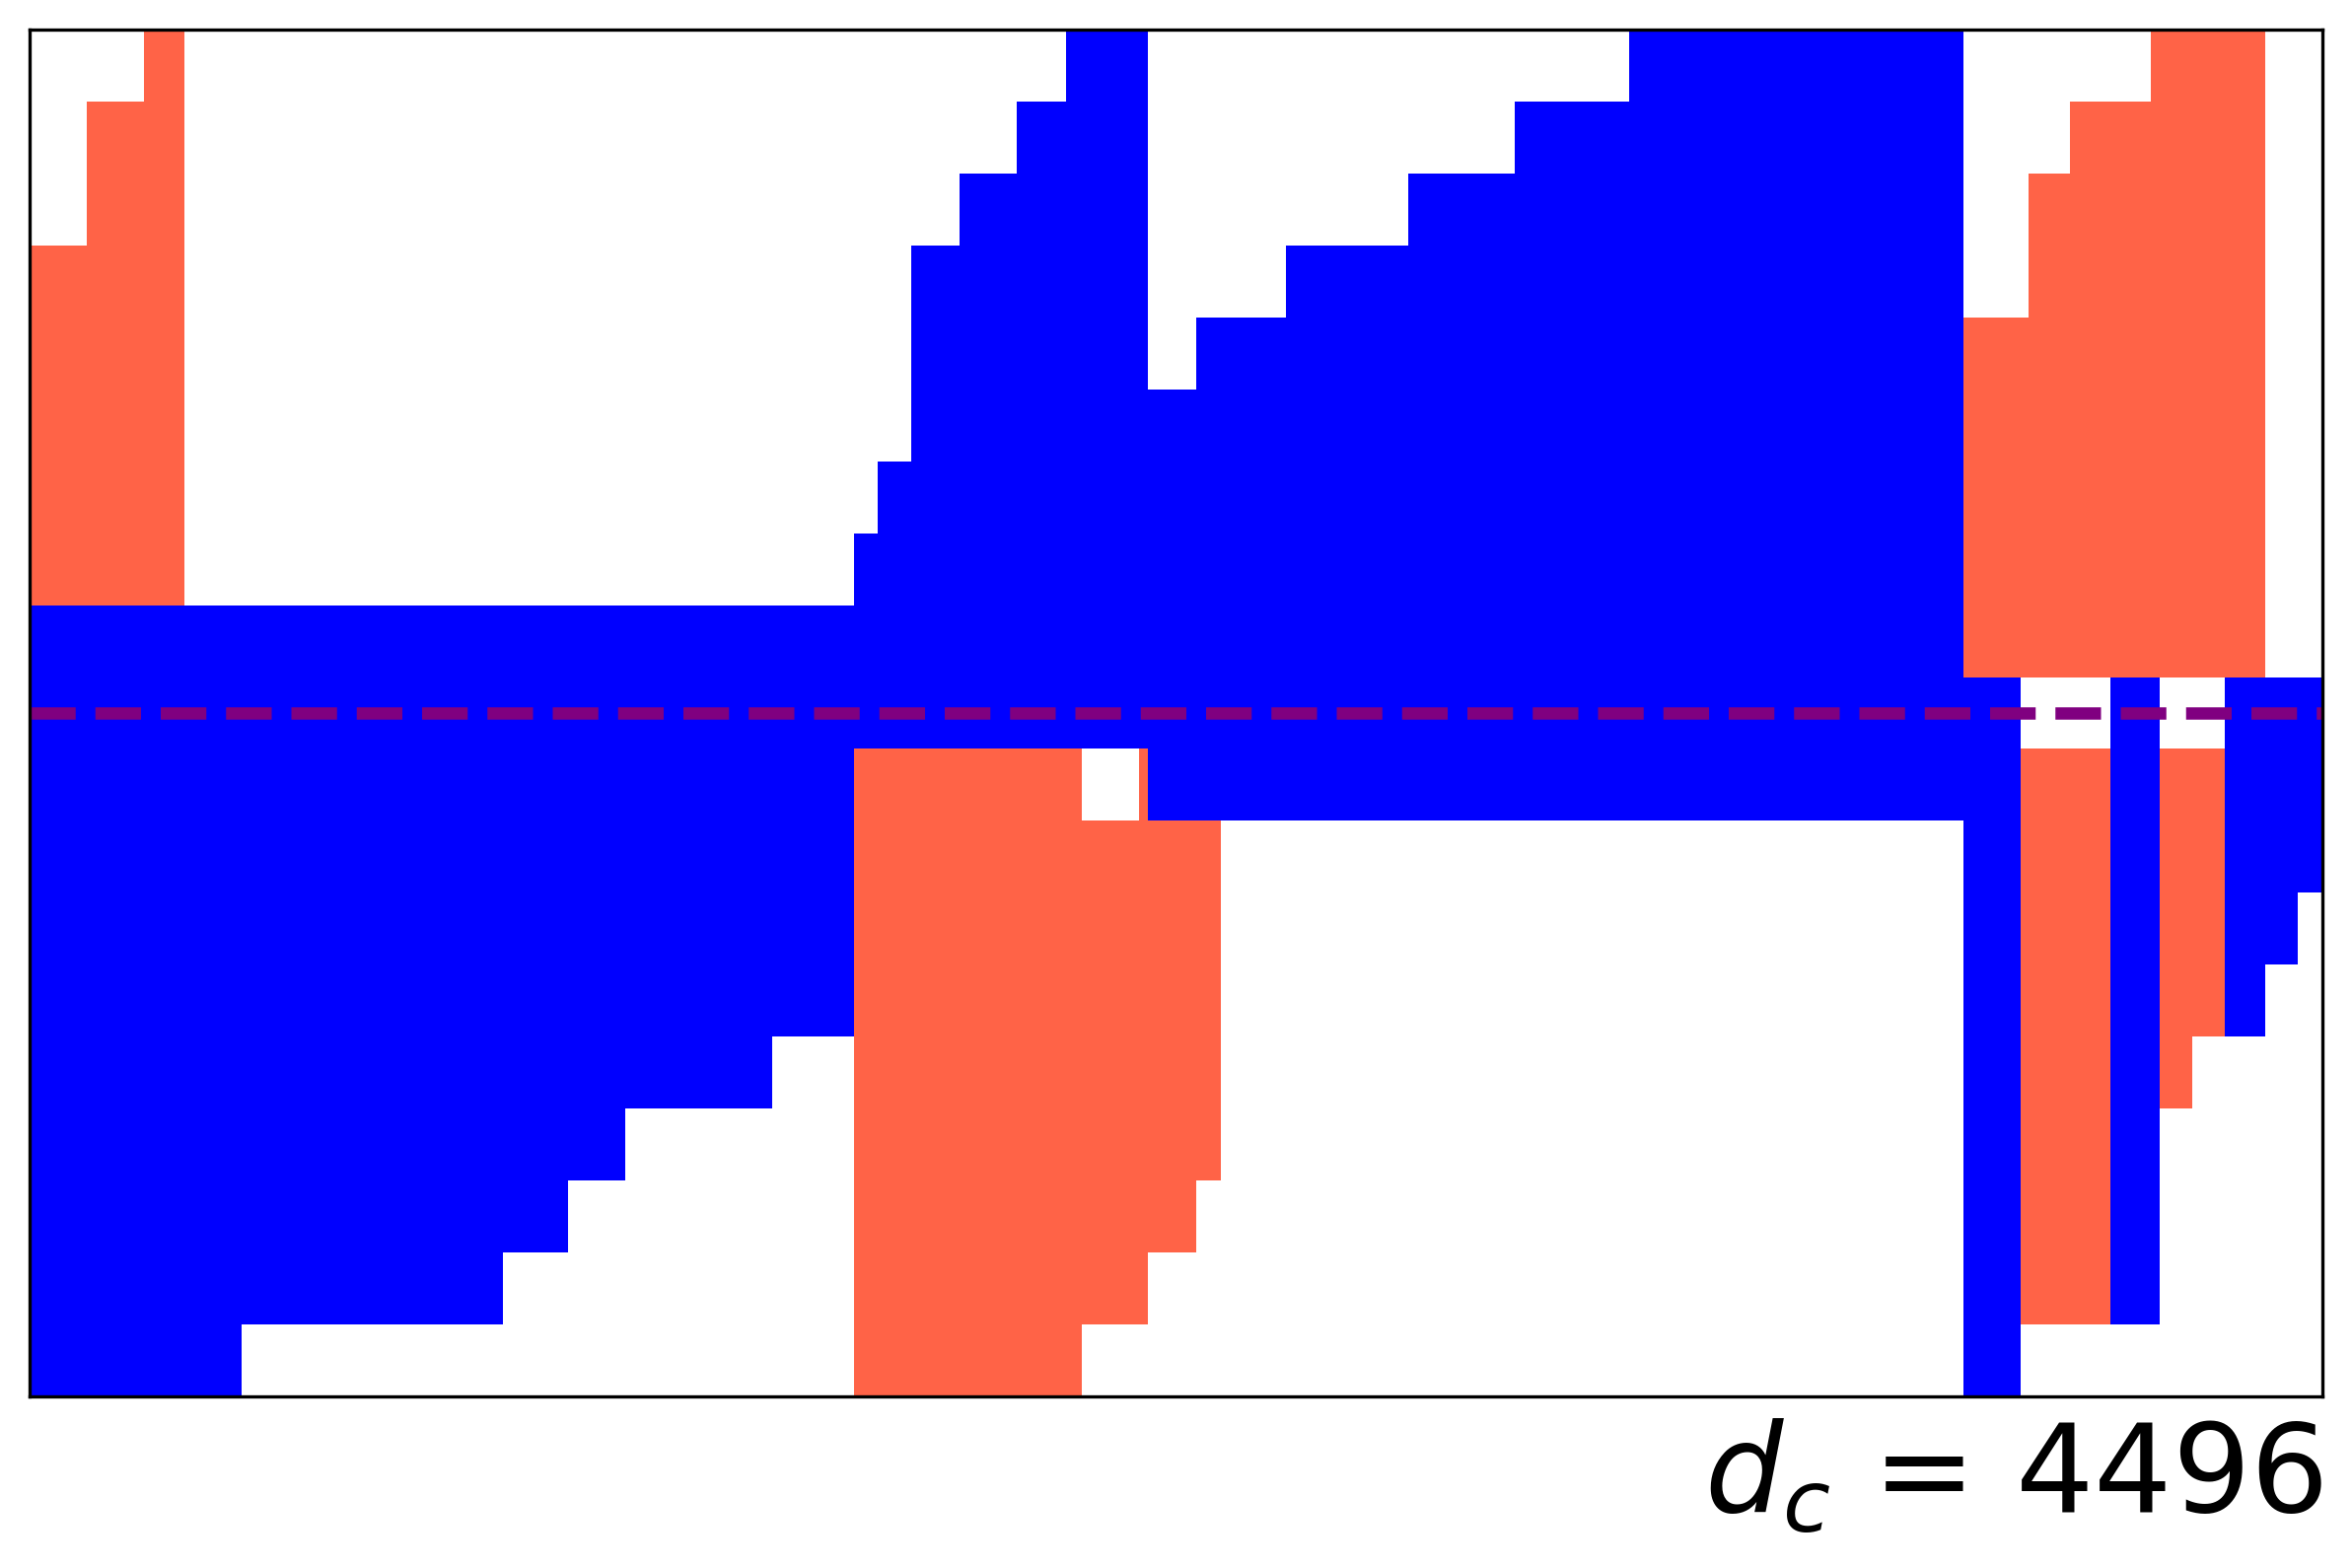

In [76]:
results_tile = process_placed_tile(placed_tiles_lst, [])
draw_packing_overlap(results_tile, bounding_width, n, seam_lst,new_inter_color="blue", new_intra_color="tomato", inter_color="blue")